In [1]:
import pandas as pd
import numpy as np

print("AI Crop Health Index Started")

AI Crop Health Index Started


In [2]:
sensor = pd.read_csv("../dataset/Smart_Farming_Crop_Yield_2024.csv")

sensor.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


In [3]:
sensor = sensor.rename(columns={
    "crop_type":"crop",
    "soil_moisture_%":"soil_moisture",
    "soil_pH":"soil_ph",
    "temperature_C":"temperature",
    "rainfall_mm":"rainfall",
    "humidity_%":"humidity",
    "NDVI_index":"ndvi"
})

In [4]:
sensor["irrigation_type"] = sensor["irrigation_type"].fillna(sensor["irrigation_type"].mode()[0])

sensor["crop_disease_status"] = sensor["crop_disease_status"].fillna(sensor["crop_disease_status"].mode()[0])

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = [
    "soil_moisture",
    "soil_ph",
    "temperature",
    "rainfall",
    "humidity",
    "sunlight_hours",
    "ndvi"
]

sensor[cols] = scaler.fit_transform(sensor[cols])

sensor.head()

,farm_id,region,crop,soil_moisture,soil_ph,temperature,rainfall,humidity,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,ndvi,crop_disease_status
0,FARM0001,North India,Wheat,0.740666,0.241206,0.140625,0.102295,0.739401,0.544240,Sprinkler,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.550000,Mild
1,FARM0002,South USA,Soybean,0.275129,0.869347,0.765121,0.159733,0.419932,0.277129,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.466667,Severe
2,FARM0003,South USA,Wheat,0.550258,0.829146,0.623488,0.865228,0.575447,0.704508,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.833333,Mild
3,FARM0004,Central USA,Maize,0.205916,0.261307,0.944052,0.650508,0.607394,0.170284,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.233333,Severe
4,FARM0005,Central USA,Cotton,0.264503,0.206030,0.950605,0.879939,0.311433,0.654424,Sprinkler,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.900000,Severe


In [6]:
sensor["soil_fertility_score"] = (
    sensor["soil_ph"] +
    sensor["soil_moisture"]
) / 2

In [7]:
sensor["weather_score"] = (
    sensor["temperature"] +
    sensor["humidity"] +
    sensor["rainfall"]
) / 3

In [8]:
sensor["vegetation_score"] = sensor["ndvi"]

In [9]:
sensor["moisture_stress_score"] = (
    sensor["soil_moisture"] +
    sensor["rainfall"]
) / 2

In [10]:
sensor["ai_crop_health_index"] = (
    0.30 * sensor["soil_fertility_score"] +
    0.25 * sensor["weather_score"] +
    0.25 * sensor["vegetation_score"] +
    0.20 * sensor["moisture_stress_score"]
)

sensor[[
    "soil_fertility_score",
    "weather_score",
    "vegetation_score",
    "moisture_stress_score",
    "ai_crop_health_index"
]].head()

,soil_fertility_score,weather_score,vegetation_score,moisture_stress_score,ai_crop_health_index
0,0.490936,0.327440,0.550000,0.421481,0.450937
1,0.572238,0.448262,0.466667,0.217431,0.443890
2,0.689702,0.688054,0.833333,0.707743,0.728806
3,0.233611,0.733985,0.233333,0.428212,0.397555
4,0.235267,0.713992,0.900000,0.572221,0.588522


In [11]:
def health_category(score):
    if score >= 0.80:
        return "Excellent"
    elif score >= 0.60:
        return "Good"
    elif score >= 0.40:
        return "Moderate"
    else:
        return "Poor"

sensor["health_status"] = sensor["ai_crop_health_index"].apply(health_category)

sensor[["ai_crop_health_index", "health_status"]].head()

,ai_crop_health_index,health_status
0,0.450937,Moderate
1,0.443890,Moderate
2,0.728806,Good
3,0.397555,Poor
4,0.588522,Moderate


In [12]:
print(sensor["health_status"].value_counts())

health_status
Moderate     266
Poor         115
Good         113
Excellent      6
Name: count, dtype: int64


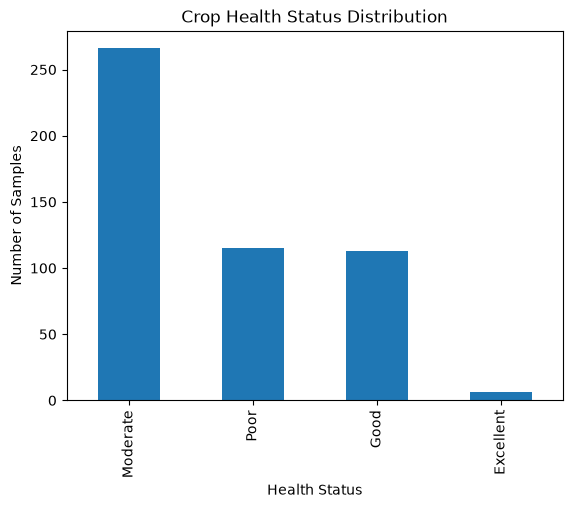

In [13]:
import matplotlib.pyplot as plt

sensor["health_status"].value_counts().plot(kind="bar")

plt.title("Crop Health Status Distribution")
plt.xlabel("Health Status")
plt.ylabel("Number of Samples")

plt.show()

In [14]:
def irrigation_advice(row):

    if row["soil_moisture"] < 0.30:
        return "High Irrigation"

    elif row["soil_moisture"] < 0.60:
        return "Moderate Irrigation"

    else:
        return "No Irrigation Needed"

sensor["irrigation_recommendation"] = sensor.apply(
    irrigation_advice,
    axis=1
)

sensor[[
    "soil_moisture",
    "irrigation_recommendation"
]].head()

,soil_moisture,irrigation_recommendation
0,0.740666,No Irrigation Needed
1,0.275129,High Irrigation
2,0.550258,Moderate Irrigation
3,0.205916,High Irrigation
4,0.264503,High Irrigation


In [15]:
sensor[[
    "crop",
    "ai_crop_health_index",
    "health_status",
    "irrigation_recommendation"
]].head(20)

,crop,ai_crop_health_index,health_status,irrigation_recommendation
0,Wheat,0.450937,Moderate,No Irrigation Needed
1,Soybean,0.443890,Moderate,High Irrigation
2,Wheat,0.728806,Good,Moderate Irrigation
3,Maize,0.397555,Poor,High Irrigation
4,Cotton,0.588522,Moderate,High Irrigation
5,Rice,0.738798,Good,No Irrigation Needed
6,Soybean,0.589899,Moderate,No Irrigation Needed
7,Maize,0.583169,Moderate,Moderate Irrigation
8,Soybean,0.542534,Moderate,No Irrigation Needed
9,Rice,0.243086,Poor,High Irrigation


In [16]:
sensor.to_csv(
    "../dataset/final_crop_health_dataset.csv",
    index=False
)

print("Final Crop Health Dataset Saved Successfully!")

Final Crop Health Dataset Saved Successfully!
